In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

# load data and clean up

In [ ]:
# Load the data
df = pd.read_csv("data/training_set_VU_DM.csv")

# add label column
df["label"] = df["booking_bool"] * 5 + (df["click_bool"] & ~df["booking_bool"]) * 1

# add relevant information from date-time, and remove the original date-time column
df['date_time'] = pd.to_datetime(df['date_time'])
df['month'] = df['date_time'].dt.month
df['weekday'] = df['date_time'].dt.weekday
df.drop(columns=['date_time'], inplace=True)

# filter unrealstic prices (price_usd)
df = df[(df["price_usd"] >= 10) & (df["price_usd"] <= 1000)]

# filter unrealistic prices for gross_bookings_usd
df = df[(df["gross_bookings_usd"].isna()) | ((df["gross_bookings_usd"] >= 10) & (df["gross_bookings_usd"] <= 2000))]

# Create label: 5 for booking, 1 for click, 0 for nothing
df["label"] = df["booking_bool"] * 5 + (df["click_bool"] & ~df["booking_bool"]) * 1


# create new features

In [ ]:
# define relative feature function
def add_relative_features(df, features, group_key="srch_id", methods=["percentile", "minmax", "zscore", "rank"]):
    df = df.copy()
    for feature in features:
        if feature not in df.columns:
            print(f"Feature '{feature}' not in DataFrame. Skipping.")
            continue
        group = df.groupby(group_key)[feature]
        if "percentile" in methods:
            df[f"{feature}_pct_rank"] = group.rank(pct=True)
        if "minmax" in methods:
            min_ = group.transform("min")
            max_ = group.transform("max")
            df[f"{feature}_minmax"] = (df[feature] - min_) / (max_ - min_ + 1e-6)
        if "zscore" in methods:
            mean = group.transform("mean")
            std = group.transform("std").replace(0, 1e-6)
            df[f"{feature}_zscore"] = (df[feature] - mean) / std
        if "rank" in methods:
            df[f"{feature}_rank"] = group.rank(method="min")
    return df

# choose features to rank
relative_features = [
    "price_usd",
    "prop_review_score",
    "prop_location_score1",
    "prop_starrating",
    "prop_location_score2",
    "prop_log_historical_price",
    "srch_length_of_stay",
    "srch_booking_window",
]

# # add all 8 comp rates
# for i in range(1, 9):
#     relative_features += [
#         f"comp{i}_rate_percent_diff",
#         f"comp{i}_rate"
#     ]


# # Choose features for relative ranking
# relative_features = [

#     "srch_adults_count",
#     "srch_children_count",
#     "srch_room_count",
#     "srch_query_affinity_score",
#     "orig_destination_distance",
#     "visitor_hist_adr_usd",         
#     "visitor_hist_starrating",      
#     "comp1_rate_percent_diff",  
# ]                


# Add relative features
df = add_relative_features(df, relative_features, methods=["percentile", "minmax", "rank", "zscore"])

# Add more features, drop others

In [6]:
print(len(df.columns.tolist()))


88


# setup up data for testing and run model (Hyperparameter tuning)

In [41]:


from itertools import product

# Define the hyperparameter grid
param_grid = {
    "num_leaves": [20, 31, 50],
    "learning_rate": [0.05, 0.1],
    "min_child_samples": [10, 20],
    "n_estimators": [100, 200],
}

# Track the best
best_score = -1
best_params = None

# Split into train/val
all_search_ids = df["srch_id"].unique()
train_ids, val_ids = train_test_split(all_search_ids, test_size=0.2, random_state=42)

train_df = df[df["srch_id"].isin(train_ids)].copy()
val_df   = df[df["srch_id"].isin(val_ids)].copy()
train_df = train_df.sort_values(by="srch_id")
val_df   = val_df.sort_values(by="srch_id")

# Create group sizes
group_sizes_train = train_df.groupby("srch_id").size().tolist()
group_sizes_val = val_df.groupby("srch_id").size().tolist()

# Drop unwanted features
to_drop = ["srch_id", "label", "position", "click_bool", "booking_bool", "gross_bookings_usd"]
existing_cols = [col for col in to_drop if col in val_df.columns]

# Final train/val sets
train_x = train_df.drop(columns=existing_cols)
val_x = val_df.drop(columns=existing_cols)
train_y = train_df["label"]
val_y = val_df["label"]


# Loop through combinations
for params in product(*param_grid.values()):
    param_dict = dict(zip(param_grid.keys(), params))

        
    # Train LightGBM ranker
    model = lgb.LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        importance_type="gain",
        early_stopping_rounds=10,
        random_state=42,
        **param_dict
    )


    model.fit(
        X=train_x,
        y=train_y,
        group=group_sizes_train,
        eval_set=[(val_x, val_y)],
        eval_group=[group_sizes_val],
        eval_at=[5],
        eval_metric="ndcg",
    )

    score = model.best_score_["valid_0"]["ndcg@5"]

    print(f"Params: {param_dict}, NDCG@5: {score:.5f}")

    if score > best_score:
        best_score = score
        best_params = param_dict

print(f"\n✅ Best Params: {best_params}, Best NDCG@5: {best_score:.5f}")


    # model.fit(
    #     X=train_x,
    #     y=train_y,
    #     group=group_sizes_train,
    #     eval_set=[(train_x, train_y), (val_x, val_y)],
    #     eval_group=[group_sizes_train, group_sizes_val],
    #     eval_at=[5],
    #     eval_metric="ndcg",
    #     eval_names=["train", "val"],
    # )

# # ✅ Plot NDCG@5 over rounds
# evals_result = model.evals_result_

# plt.figure(figsize=(10, 5))
# plt.plot(evals_result["train"]["ndcg@5"], label="Train NDCG@5")
# plt.plot(evals_result["val"]["ndcg@5"], label="Validation NDCG@5")
# plt.xlabel("Boosting Round")
# plt.ylabel("NDCG@5")
# plt.title("NDCG@5 over Boosting Rounds")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # ✅ Print final score
# final_val_score = evals_result["val"]["ndcg@5"][-1]
# print(f"Final NDCG@5 on validation set: {final_val_score:.5f}")





      






[LightGBM] [Warning] early_stopping_round is set=10, early_stopping_rounds=10 will be ignored. Current value: early_stopping_round=10
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.219544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9790
[LightGBM] [Info] Number of data points in the train set: 3948416, number of used features: 62
[LightGBM] [Warning] early_stopping_round is set=10, early_stopping_rounds=10 will be ignored. Current value: early_stopping_round=10
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's ndcg@5: 0.391441
Params: {'num_leaves': 20, 'learning_rate': 0.05, 'min_child_samples': 10, 'n_estimators': 100}, NDCG@5: 0.39144
[LightGBM] [Warning] early_stopping_round is set=10, early_stopping_rounds=10 will be ignored. Current value: early_stoppi

# Feature importance

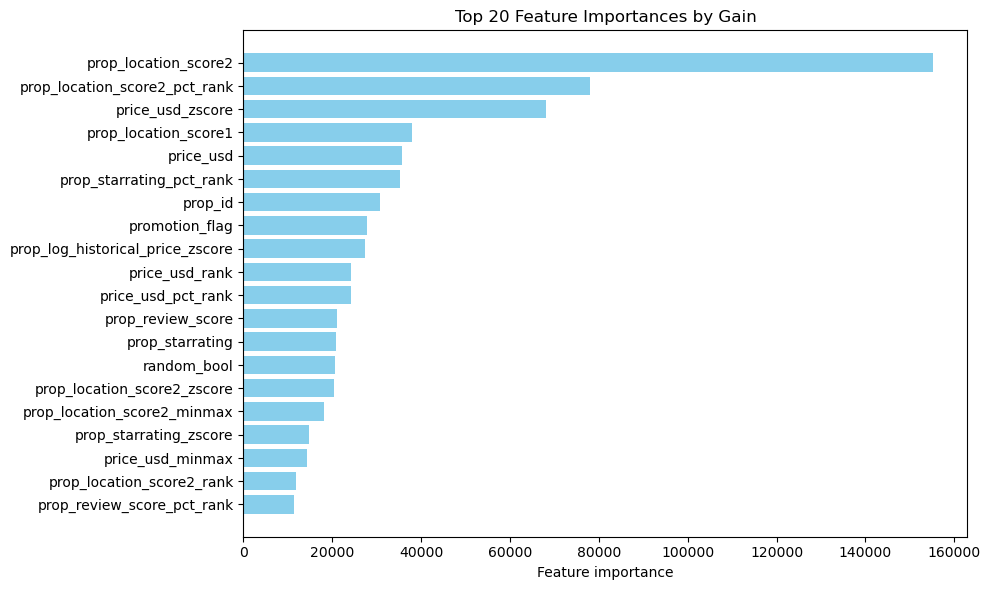

In [35]:

# ✅ Get feature importances (by gain)
importances = model.booster_.feature_importance(importance_type='gain')
feature_names = model.booster_.feature_name()

# ✅ Combine and sort
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(20)

# ✅ Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"], color="skyblue")
plt.xlabel("Feature importance")
plt.title("Top 20 Feature Importances by Gain")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# drop lowesr 32 features

In [42]:
# # drop lowest features and add more
# lowest_features = feat_imp["feature"].tolist()
# df = df.drop(columns=lowest_features)

print(df.columns.tolist())


['srch_id', 'site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag', 'srch_length_of_stay', 'srch_booking_window', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'comp8_rate_percent_diff', 'click_bool', 'gross_bookings_usd', 'booking_bool', 'label', 'price_usd_pct_rank', 'price_usd_minmax', 'price_usd_zscore', 'price_usd_rank', 'prop_review_score_pct_rank', 'prop_review_score_zscore', 'prop_review_score_rank', 'prop_location_score1_pct_rank', 'prop_location_score1_minmax', 'prop_location_score1_zscore', 'prop_location_score1_rank', 'prop_starrating_pct_rank', 'prop_starrating_minmax', 'prop_starrating_zscore', 'prop_starrating_rank', 'prop_location_score2_pct_rank', 'prop_location_score2_minmax', 'prop_location_score2_z

In [33]:
# relative_features_3 = []
# relative_features_3 = [
#     "srch_adults_count",
#     "srch_children_count",
#     "srch_room_count",
#     "srch_query_affinity_score",
#     "orig_destination_distance",
#     "visitor_hist_adr_usd",         
#     "visitor_hist_starrating",      
#     "comp1_rate_percent_diff",  
# ]   


# # Add relative features
# df = add_relative_features(df, relative_features_3, methods=["percentile", "minmax", "rank", "zscore"])

# print(len(df.columns.tolist()))

# # relative expense feature 
# df["relative_expense"] = df["price_usd"] / df["visitor_hist_adr_usd"]

# # relative quality feature
# df["star_rating_diff"] = df["prop_starrating"] - df["visitor_hist_starrating"]

print(len(df.columns.tolist()))

68


In [ ]:
from itertools import product

# Define the hyperparameter grid
param_grid = {
    "num_leaves": [20, 31, 50],
    "learning_rate": [0.05, 0.1],
    "min_child_samples": [10, 20],
    "n_estimators": [100, 200],
}

# Track the best
best_score = -1
best_params = None

# Loop through combinations
for params in product(*param_grid.values()):
    param_dict = dict(zip(param_grid.keys(), params))

    model = lgb.LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        importance_type="gain",
        early_stopping_rounds=10,
        random_state=42,
        **param_dict
    )

    model.fit(
        X=train_x,
        y=train_y,
        group=group_sizes_train,
        eval_set=[(val_x, val_y)],
        eval_group=[group_sizes_val],
        eval_at=[5],
        eval_metric="ndcg",
        verbose=-1
    )

    score = model.best_score_["valid_0"]["ndcg@5"]

    print(f"Params: {param_dict}, NDCG@5: {score:.5f}")

    if score > best_score:
        best_score = score
        best_params = param_dict

print(f"\n✅ Best Params: {best_params}, Best NDCG@5: {best_score:.5f}")
